In [11]:
# core tools + turn off a harmless pandas warning we don't need
import pandas as pd, numpy as np, statsmodels.api as sm
from scipy import stats
import seaborn as sns, matplotlib.pyplot as plt
pd.set_option('future.no_silent_downcasting', True)

In [12]:
# load all 4 raw files and check their sizes
experiments = pd.read_csv("../data/experiments.csv")
assignments = pd.read_csv("../data/assignments.csv")
events = pd.read_csv("../data/events.csv")
users = pd.read_csv("../data/users.csv")
print(experiments.shape, assignments.shape, events.shape, users.shape)

(10, 9) (93050, 5) (619048, 7) (46000, 8)


In [13]:
# event_date had 3 different formats mixed together, this fixes all of them at once
events["event_date"] = pd.to_datetime(events["event_date"], format="mixed", dayfirst=True)
print(events["event_date"].isna().sum())

0


In [14]:
# only keep the experiments Beri marked as trustworthy, drop EXP-005 and EXP-010
ANALYSABLE = ["EXP-001","EXP-002","EXP-003","EXP-004","EXP-006","EXP-007","EXP-008","EXP-009"]
assignments = assignments[assignments.experiment_id.isin(ANALYSABLE)]
events = events[events.experiment_id.isin(ANALYSABLE)]

In [15]:
# combine all 3 tables into one, so each row has variant, user info, and their outcome together
merged = assignments.merge(users, on="user_id", how="left").merge(events, on=["experiment_id","user_id"], how="left")
print(len(merged), merged["converted"].isna().sum())

476457 117


In [16]:
# for each experiment: run regression, run CUPED, check every segment for a reversal
regression_results = []
cuped_results = []
all_segment_rows = []

for exp_id in ANALYSABLE:
    test = merged[merged.experiment_id == exp_id].copy()

    # regression: effect of variant, controlling for device/country/channel
    dummies = pd.get_dummies(test, columns=["device","country","acquisition_channel"], drop_first=True)
    dummies["variant_treated"] = (dummies["variant"]=="treatment").astype(int)
    cov_cols = [c for c in dummies.columns if c.startswith(("device_","country_","acquisition_channel_"))]
    X = sm.add_constant(dummies[["variant_treated"]+cov_cols])
    y = dummies["converted"].fillna(False).astype(int)
    model = sm.OLS(y, X).fit()
    eff = model.params["variant_treated"]
    lo, hi = model.conf_int().loc["variant_treated"]
    regression_results.append({"experiment_id":exp_id,"effect":round(eff,4),"ci_low":round(lo,4),"ci_high":round(hi,4)})

    # CUPED: use pre-period revenue to try to shrink the confidence interval
    ul = test.groupby("user_id").agg(variant=("variant","first"), revenue=("revenue_xaf","sum"), pre_revenue_28d=("pre_revenue_28d","first")).reset_index()
    cov = np.cov(ul["revenue"], ul["pre_revenue_28d"])[0][1]
    var = np.var(ul["pre_revenue_28d"], ddof=1)
    theta = cov/var if var != 0 else 0
    mean_pre = ul["pre_revenue_28d"].mean()
    ul["adjusted_revenue"] = ul["revenue"] - theta*(ul["pre_revenue_28d"]-mean_pre)

    def ci_width(a,b):
        d = b.mean()-a.mean()
        se = np.sqrt(a.var(ddof=1)/len(a)+b.var(ddof=1)/len(b))
        return 2*1.96*se

    c_raw, t_raw = ul[ul.variant=="control"]["revenue"], ul[ul.variant=="treatment"]["revenue"]
    c_adj, t_adj = ul[ul.variant=="control"]["adjusted_revenue"], ul[ul.variant=="treatment"]["adjusted_revenue"]
    wb, wa = ci_width(c_raw,t_raw), ci_width(c_adj,t_adj)
    reduction = (1-wa/wb)*100 if wb != 0 else 0
    cuped_results.append({"experiment_id":exp_id,"width_before":round(wb,2),"width_after":round(wa,2),"reduction_pct":round(reduction,1)})

    # segments: check the effect separately per device/country/channel value
    for col in ["device","country","acquisition_channel"]:
        for val in test[col].dropna().unique():
            sub = test[test[col]==val]
            ctrl = sub[sub.variant=="control"]["converted"].fillna(False).astype(int)
            trt = sub[sub.variant=="treatment"]["converted"].fillna(False).astype(int)
            if len(ctrl)<5 or len(trt)<5: continue
            d = trt.mean()-ctrl.mean()
            se = np.sqrt(ctrl.var(ddof=1)/len(ctrl)+trt.var(ddof=1)/len(trt))
            all_segment_rows.append({"experiment_id":exp_id,"segment_type":col,"segment_value":val,"effect":round(d,4),"ci_low":round(d-1.96*se,4),"ci_high":round(d+1.96*se,4)})

    print(f"done: {exp_id}")

# turn the collected lists into tables
regression_df = pd.DataFrame(regression_results)
cuped_df = pd.DataFrame(cuped_results)
segment_df = pd.DataFrame(all_segment_rows)
print(regression_df)

done: EXP-001
done: EXP-002
done: EXP-003
done: EXP-004
done: EXP-006
done: EXP-007
done: EXP-008
done: EXP-009
  experiment_id  effect  ci_low  ci_high
0       EXP-001  0.0008 -0.0044   0.0059
1       EXP-002  0.0094  0.0042   0.0146
2       EXP-003  0.0040 -0.0002   0.0081
3       EXP-004  0.0107  0.0037   0.0177
4       EXP-006  0.0052  0.0009   0.0095
5       EXP-007  0.0025 -0.0029   0.0079
6       EXP-008  0.0016 -0.0053   0.0086
7       EXP-009 -0.0002 -0.0055   0.0050


In [17]:
# actually write the 3 result tables to files, this step was missing before
regression_df.to_csv("../output/regression_results.csv", index=False)
cuped_df.to_csv("../output/cuped_comparison.csv", index=False)
segment_df.to_csv("../output/segment_results.csv", index=False)
print("saved")

saved


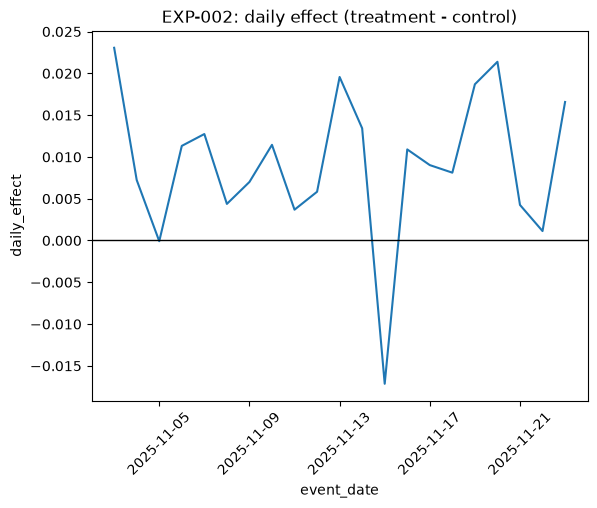

In [18]:
# check if EXP-002's effect held steady day by day, save the table and a chart
test = merged[merged.experiment_id=="EXP-002"]
daily = test.groupby(["event_date","variant"])["converted"].mean().reset_index().pivot(index="event_date", columns="variant", values="converted")
daily["daily_effect"] = daily["treatment"] - daily["control"]
daily.reset_index().to_csv("../output/effect_over_time_EXP-002.csv", index=False)

sns.lineplot(x=daily.index, y=daily["daily_effect"])
plt.axhline(0, color="black", linewidth=1)
plt.title("EXP-002: daily effect (treatment - control)")
plt.xticks(rotation=45)
plt.savefig("../output/effect_over_time_EXP-002.png")
plt.show()